# Results Analysis

In [1]:
import pandas as pd
import numpy as np


In [2]:
df = pd.read_csv('/Users/rafaelteodoro/Documents/Data Science & Programing/Repository/SOFI_BAA/sofi_results.csv')
df.head()

,k-fold,n_img,sex,gp,best_permutation,solution_fitness
0,0,0,200,5.00,[7 2 5 6 4 1 3],0.550675
1,0,1,100,6.83,[7 1 2 5 4 3 6],1.203897
2,0,2,200,5.00,[7 2 4 3 1 5 6],0.679063
3,0,3,100,6.83,[7 2 1 6 5 4 3],1.114874
4,0,4,200,6.00,[2 7 6 1 4 3 5],0.754718


In [3]:
# Treat best_permutation column to convert from string to list
df['best_permutation'] = df.best_permutation.str.replace('[', '').str.replace(']', '').str.replace('  ', ' ')
df['best_permutation'] = df.best_permutation.str.split(' ')

# convert to int
df['best_permutation'] = df.best_permutation.apply(lambda x: [int(i) for i in x if i != ''])

df.head()

,k-fold,n_img,sex,gp,best_permutation,solution_fitness
0,0,0,200,5.00,"[7, 2, 5, 6, 4, 1, 3]",0.550675
1,0,1,100,6.83,"[7, 1, 2, 5, 4, 3, 6]",1.203897
2,0,2,200,5.00,"[7, 2, 4, 3, 1, 5, 6]",0.679063
3,0,3,100,6.83,"[7, 2, 1, 6, 5, 4, 3]",1.114874
4,0,4,200,6.00,"[2, 7, 6, 1, 4, 3, 5]",0.754718


In [4]:
best_2 , middle_3 , worst_2 = [[], []], [[], []], [[], []]
for i in range(len(df)):

    if df.sex[i] == 100:
        sex_ = 0
    else:
        sex_ = 1

    # store the first 6 elements of best_permutation in list
    best_2[sex_].extend(df.best_permutation[i][:2])
    middle_3[sex_].extend(df.best_permutation[i][2:5])
    worst_2[sex_].extend(df.best_permutation[i][-2:])

In [5]:
obb_cls =   {1: 'ulna', 2: 'radius', 3: 'distal_phalanges', 4: 'middle_phalanges', 5: 'proximal_phalanges_and_metacarpus', 6: 'hand+wrist', 7: 'carpal'}

## Global

In [6]:
class_names = [obb_cls[i] for i in range(1, 8)]
class_names

['ulna',
 'radius',
 'distal_phalanges',
 'middle_phalanges',
 'proximal_phalanges_and_metacarpus',
 'hand+wrist',
 'carpal']

# using sns, create a bar plot with df where x-axis is the position from 0 to 6, y-axis is the number of times an specific joint number (1-7) appeared in that position df.permutation, and each bar is a joint in obb_cls distinguised by color


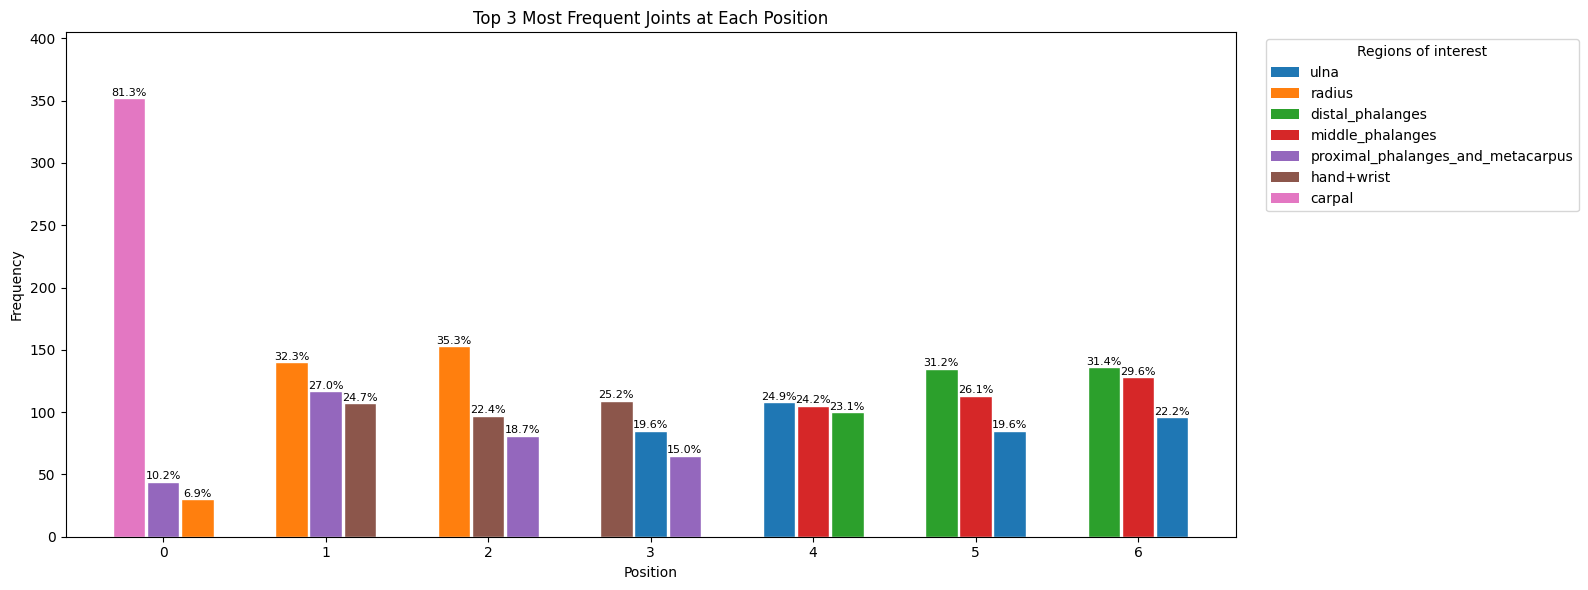

In [7]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns

from matplotlib.patches import Patch

def plot_top_joints_by_position(
    df_results,
    obb_cls,
    top_n=3,
    sex=None,
    age_range=None,
    age_df=None,
    permutation_col='best_permutation',
    sex_col='sex',
    img_id_col='n_img',
    age_df_img_id_col='k_fold_id',
    age_col='gp',
    figsize=(16, 6),
    palette_name='tab10'
 ):
    """
    Plot top-N joints by position with bars sorted inside each position.

    Parameters:
    - sex: None, 'female'/'male', 100/200, 0/1
    - age_range: None or tuple(min_age, max_age), inclusive
    - age_df: dataframe with age mapping; if None, uses gp column already in df_results
    """
    work_df = df_results.copy()

    # Ensure permutation column is a list of ints
    sample = work_df[permutation_col].dropna().iloc[0]
    if not isinstance(sample, list):
        work_df[permutation_col] = (
            work_df[permutation_col]
            .astype(str)
            .str.replace('[', '', regex=False)
            .str.replace(']', '', regex=False)
            .str.replace('  ', ' ', regex=False)
            .str.split(' ')
)
        work_df[permutation_col] = work_df[permutation_col].apply(lambda x: [int(i) for i in x if i != ''])

    if sex is not None:
        sex_map = {
            'female': 100,
            'f': 100,
            100: 100,
            0: 100,
            'male': 200,
            'm': 200,
            200: 200,
            1: 200,
        }
        sex_key = str(sex).lower() if isinstance(sex, str) else sex
        if sex_key not in sex_map:
            raise ValueError("sex must be one of: None, 'female', 'male', 100, 200, 0, 1")
        work_df = work_df[work_df[sex_col] == sex_map[sex_key]]

    if age_range is not None:
        min_age, max_age = age_range
        if age_df is None:
            work_df = work_df[(work_df[age_col] >= min_age) & (work_df[age_col] <= max_age)]
        else:
            age_map = age_df[[age_df_img_id_col, age_col]].rename(columns={age_df_img_id_col: img_id_col})
            work_df = work_df.merge(age_map, on=img_id_col, how='left')
            work_df = work_df[(work_df[age_col] >= min_age) & (work_df[age_col] <= max_age)]

    if work_df.empty:
        raise ValueError('No rows left after applying filters. Check sex/age_range values.')

    joint_ids = sorted(obb_cls.keys())
    position_joint = pd.DataFrame(work_df[permutation_col].tolist())
    n_positions = position_joint.shape[1]
    position_joint.columns = range(n_positions)

    freq_df = (
        position_joint
        .melt(var_name='position', value_name='joint')
        .query('joint in @joint_ids')
        .groupby(['position', 'joint'])
        .size()
        .reset_index(name='count')
)

    all_combinations = pd.MultiIndex.from_product([range(n_positions), joint_ids], names=['position', 'joint']).to_frame(index=False)
    freq_df = all_combinations.merge(freq_df, on=['position', 'joint'], how='left').fillna({'count': 0})
    freq_df['count'] = freq_df['count'].astype(int)
    freq_df['joint_name'] = freq_df['joint'].map(obb_cls)

    topn_df = (
        freq_df.sort_values(['position', 'count'], ascending=[True, False])
        .groupby('position', as_index=False, group_keys=False)
        .head(top_n)
        .copy()
        .sort_values(['position', 'count'], ascending=[True, False])
)
    topn_df['pct'] = 100 * topn_df['count'] / len(work_df)

    positions = sorted(topn_df['position'].unique())
    joint_order = [obb_cls[i] for i in joint_ids]
    palette = sns.color_palette(palette_name, n_colors=len(joint_order))
    color_map = dict(zip(joint_order, palette))

    fig, ax = plt.subplots(figsize=figsize)
    bar_width = 0.8 / (top_n + 0.8)
    offsets = np.linspace(-bar_width * (top_n - 1) / 2, bar_width * (top_n - 1) / 2, top_n)

    for pos in positions:
        sub = topn_df[topn_df['position'] == pos].sort_values('count', ascending=False).reset_index(drop=True)
        for i, row in sub.iterrows():
            x = pos + offsets[i]
            ax.bar(x, row['count'], width=bar_width * 0.95, color=color_map[row['joint_name']], edgecolor='white')
            ax.text(x, row['count'] + 0.35, f"{row['pct']:.1f}%", ha='center', va='bottom', fontsize=8)

    title_parts = [f"Top {top_n} Most Frequent Joints at Each Position"]
    if sex is not None:
        sex_label = 'female' if sex_map[sex_key] == 100 else 'male'
        title_parts.append(f"sex={sex_label}")
    if age_range is not None:
        title_parts.append(f"age={min_age}-{max_age}")

    ax.set_title(' | '.join(title_parts))
    ax.set_xlabel('Position')
    ax.set_ylabel('Frequency')
    ax.set_xticks(positions)
    ax.set_xticklabels(positions)
    ax.set_xlim(min(positions) - 0.6, max(positions) + 0.6)
    ax.set_ylim(0, topn_df['count'].max() * 1.15)

    legend_handles = [Patch(facecolor=color_map[joint], label=joint) for joint in joint_order]
    ax.legend(handles=legend_handles, title='Regions of interest', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()

    return topn_df, ax

# Example usage
top3_global, _ = plot_top_joints_by_position(df, obb_cls, top_n=3)

# Additional examples:
# top3_female, _ = plot_top_joints_by_position(df, obb_cls, top_n=3, sex='female')
# top3_male_10_14, _ = plot_top_joints_by_position(df, obb_cls, top_n=3, sex='male', age_range=(10, 14))

## Global Female and by range of age

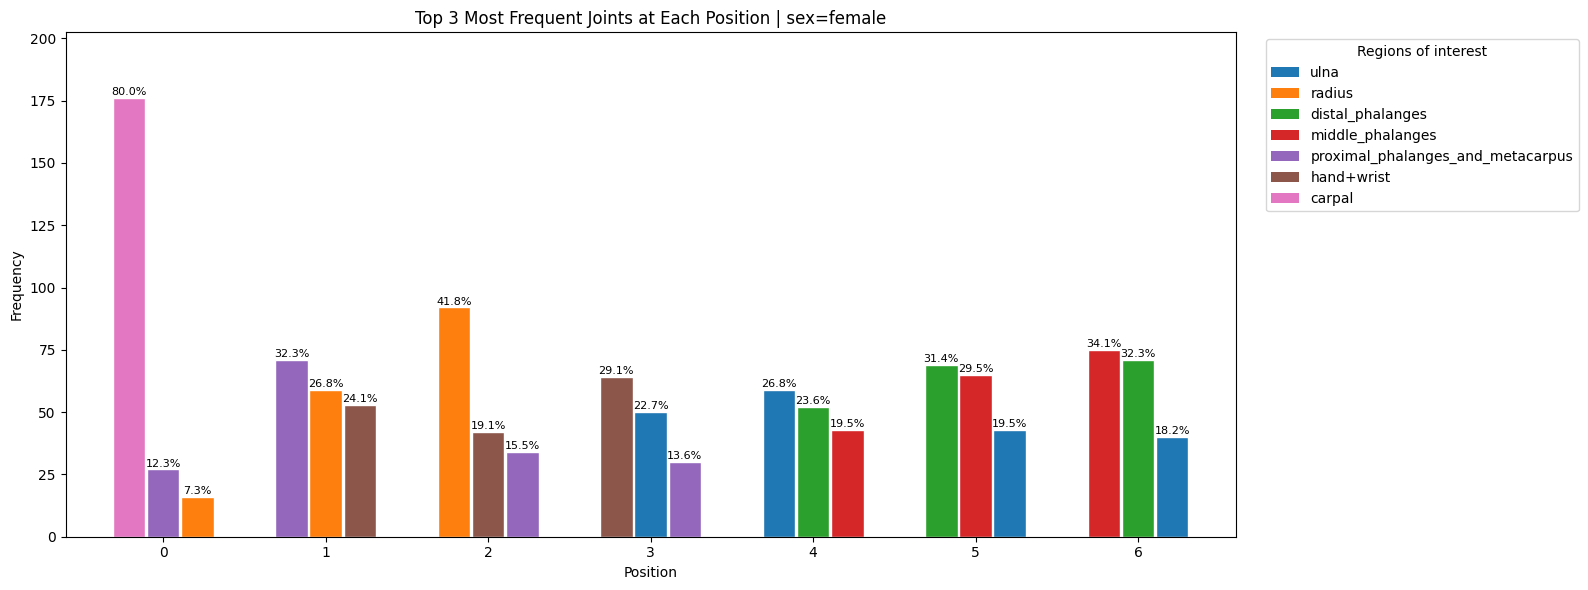

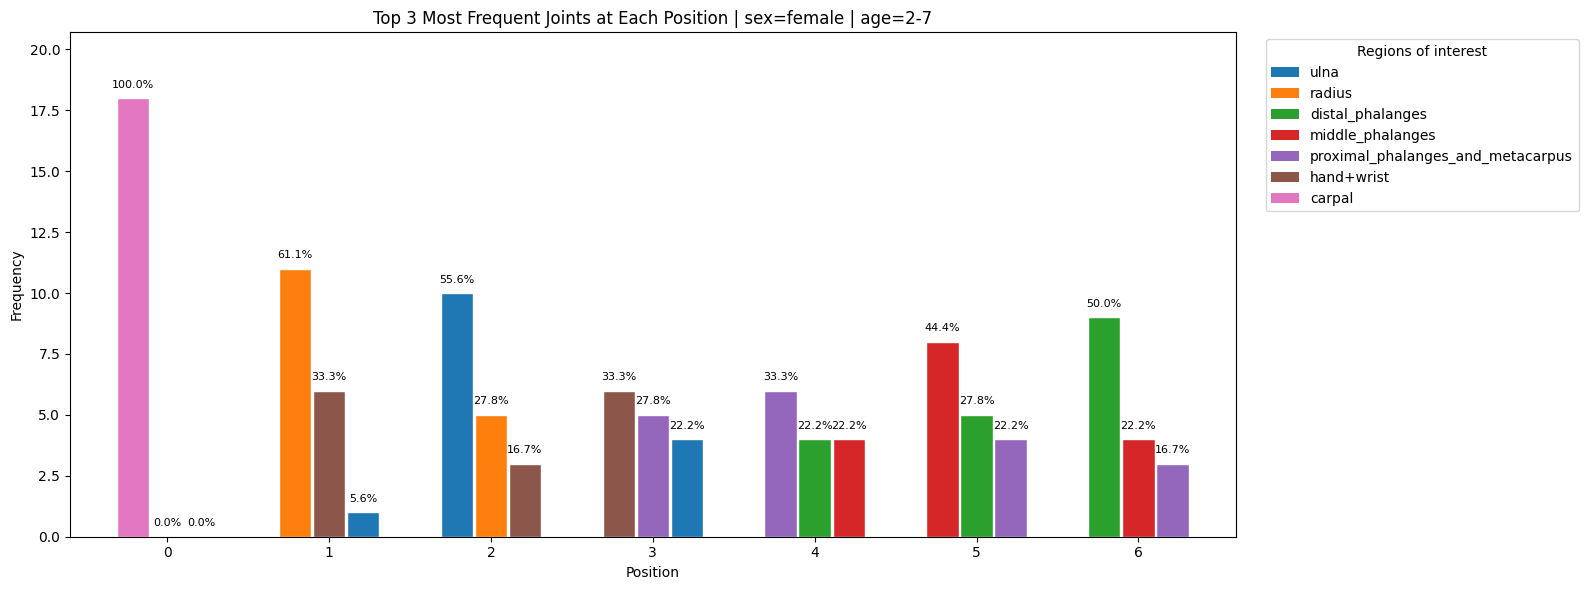

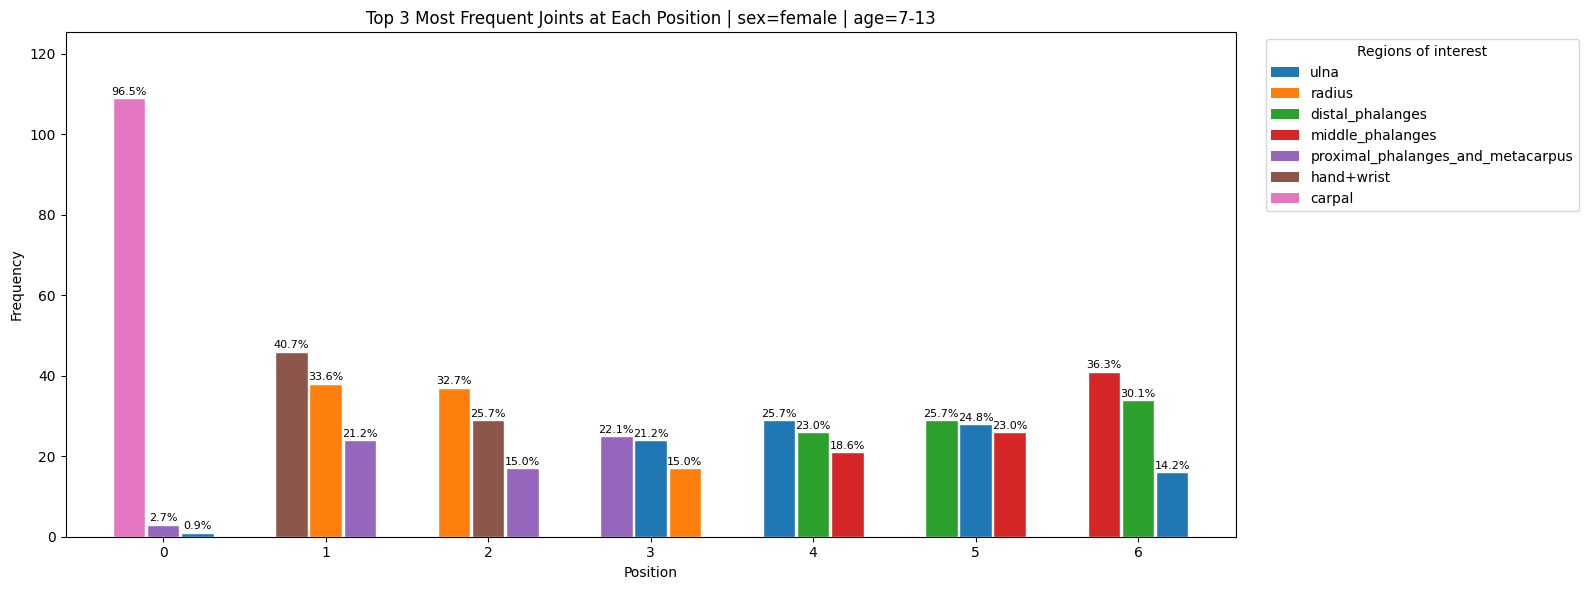

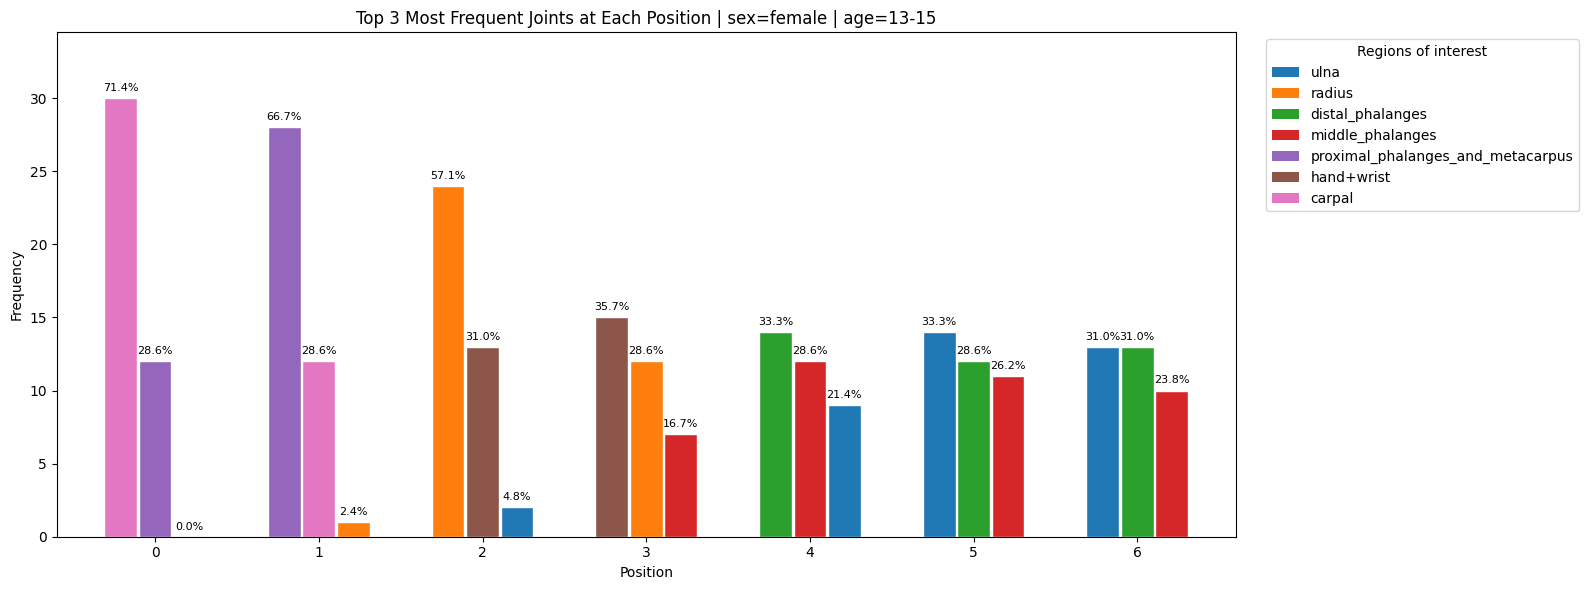

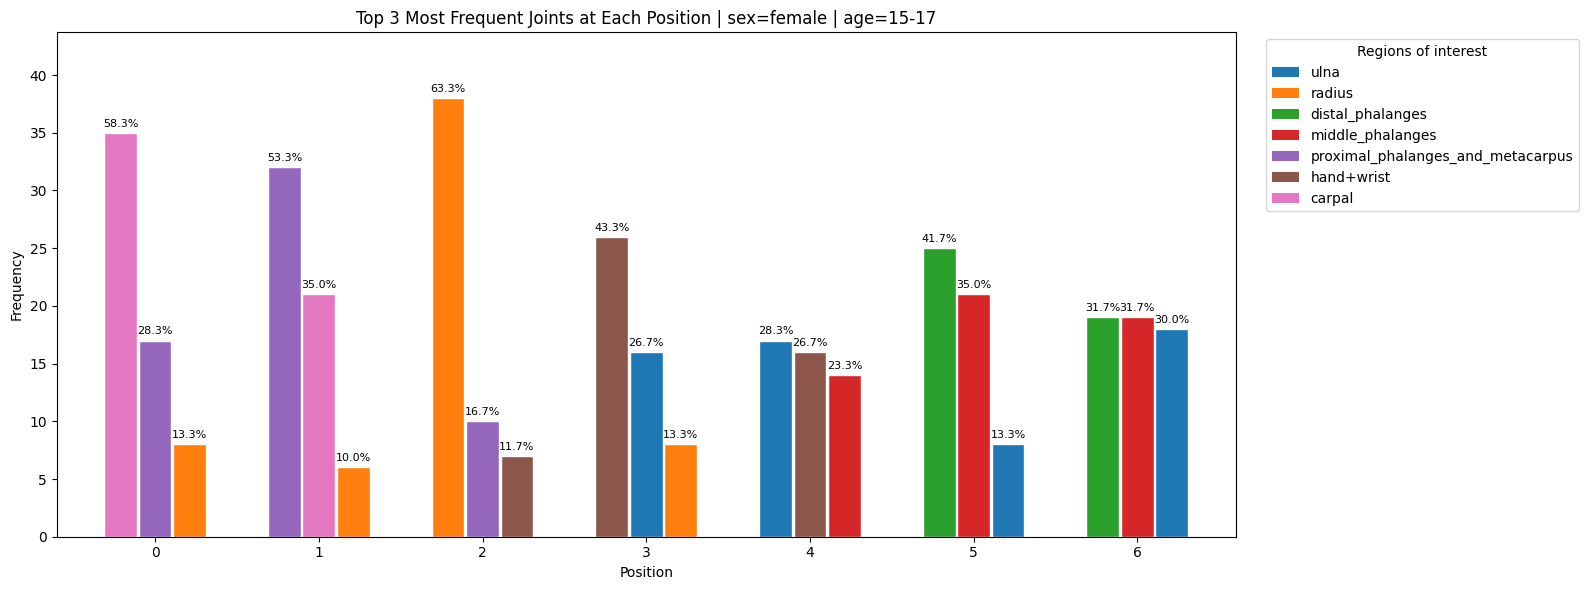

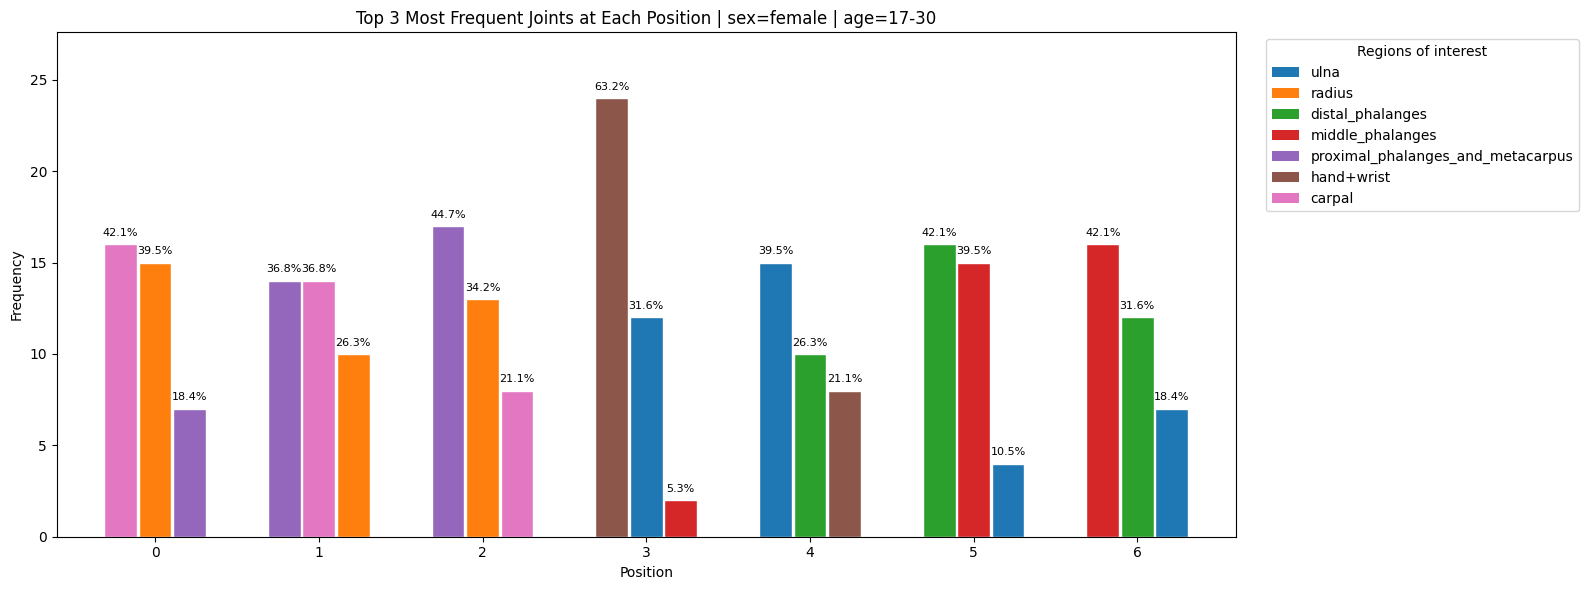

In [8]:
top3_female, _ = plot_top_joints_by_position(df, obb_cls, top_n=3, sex='female')
top3_female_2_7, _ = plot_top_joints_by_position(df, obb_cls, top_n=3, sex='female', age_range=(2, 7))
top3_female_7_13, _ = plot_top_joints_by_position(df, obb_cls, top_n=3, sex='female', age_range=(7, 13))
top3_female_13_15, _ = plot_top_joints_by_position(df, obb_cls, top_n=3, sex='female', age_range=(13, 15))
top3_female_15_17, _ = plot_top_joints_by_position(df, obb_cls, top_n=3, sex='female', age_range=(15, 17))
top3_female_17_20, _ = plot_top_joints_by_position(df, obb_cls, top_n=3, sex='female', age_range=(17, 30))

## Male global and by range of age

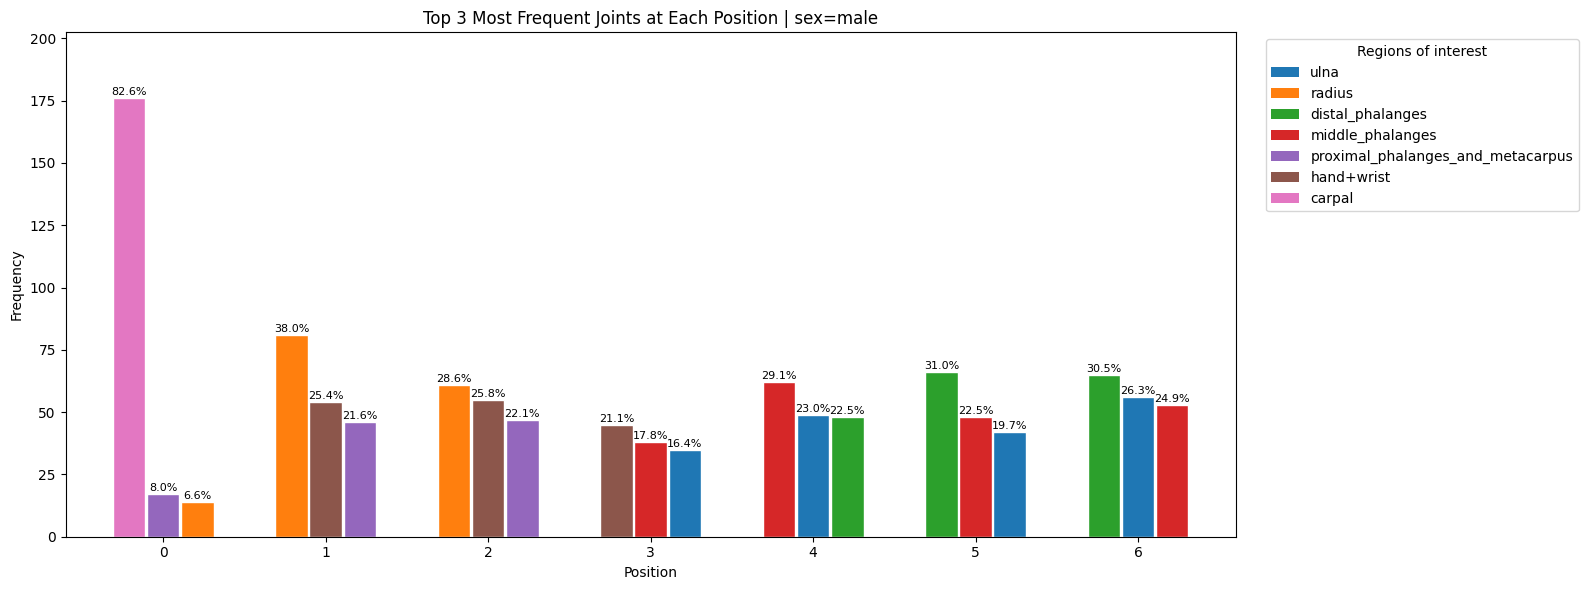

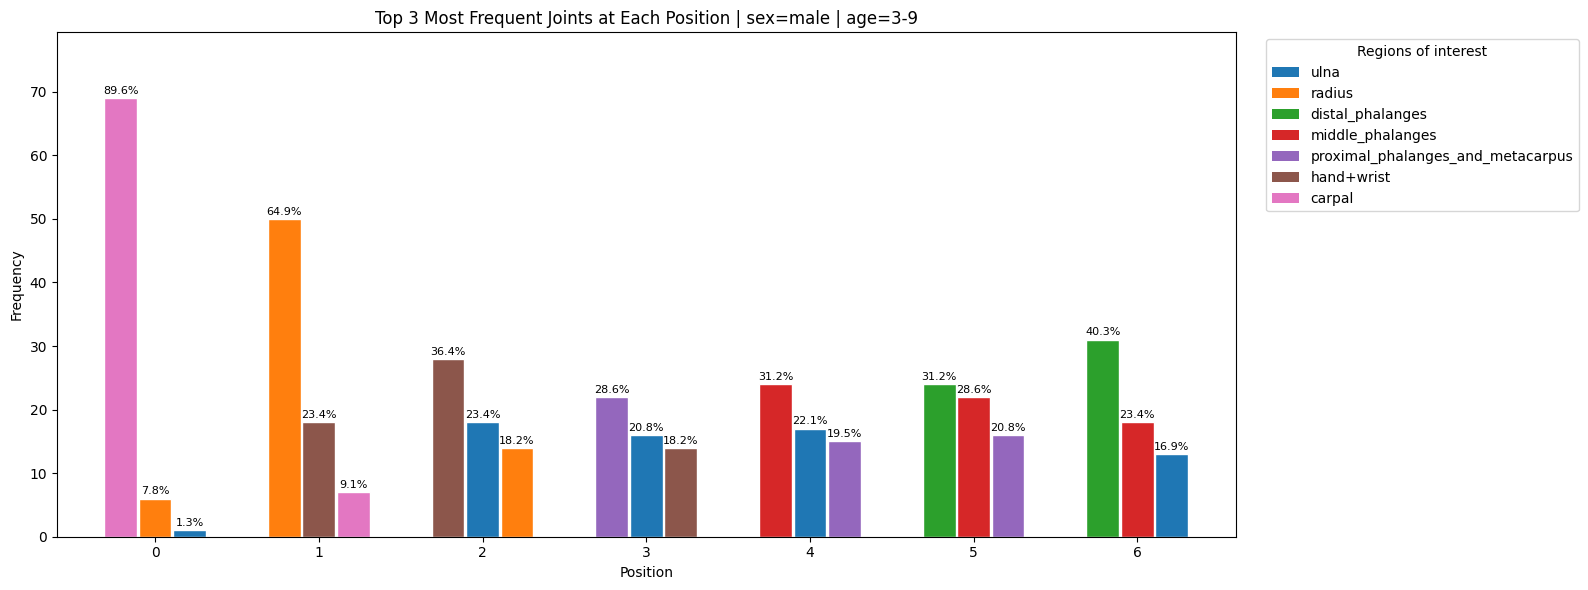

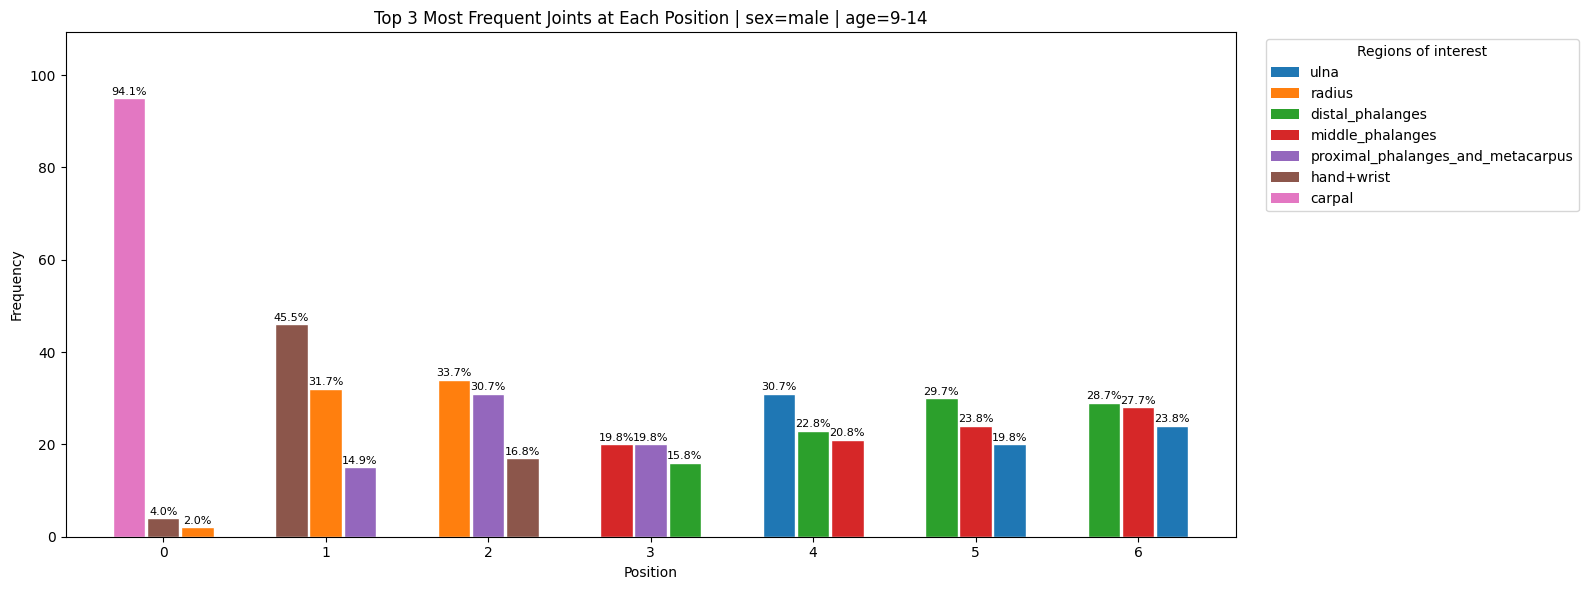

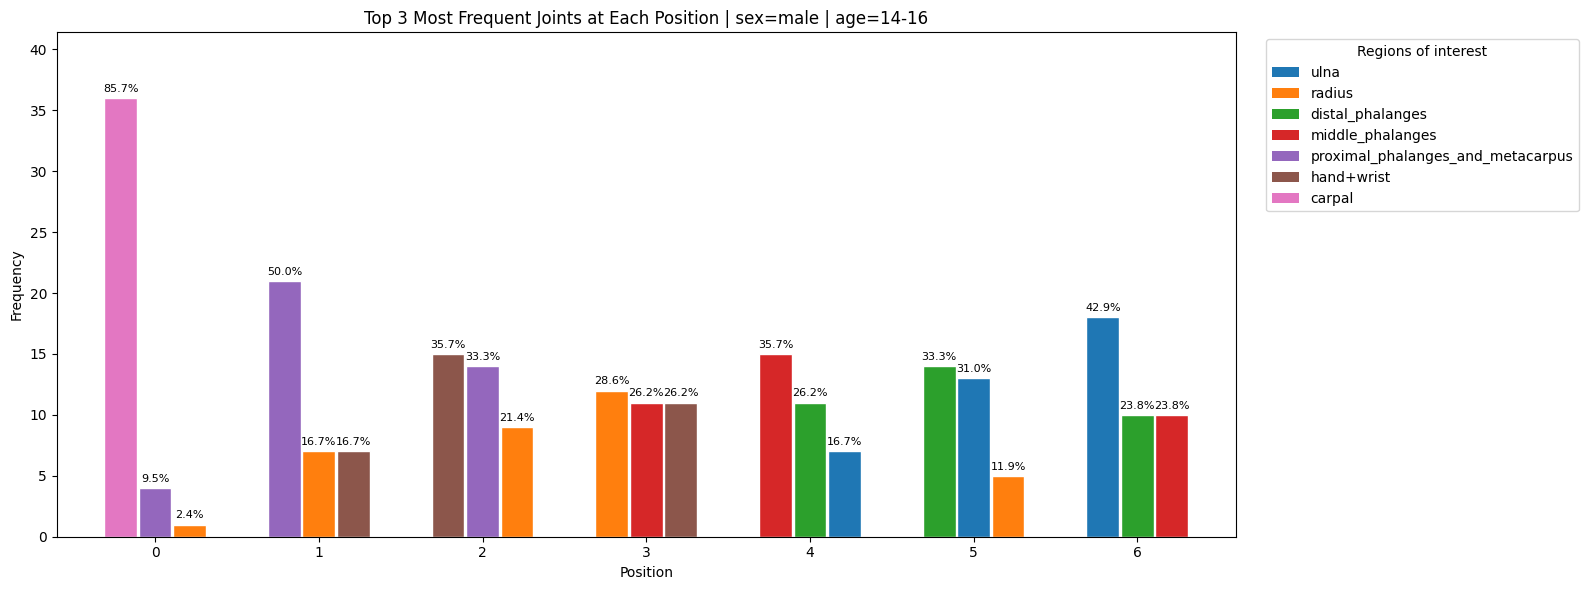

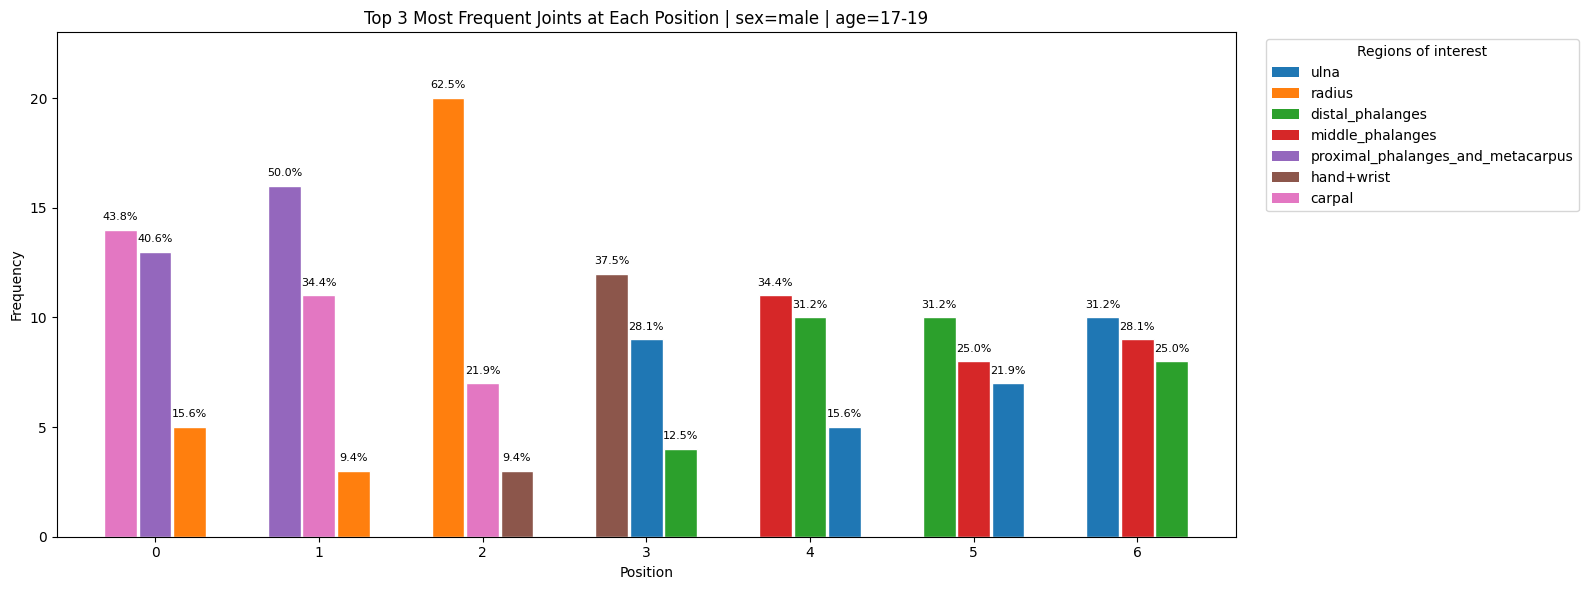

In [9]:
top3_male, _ = plot_top_joints_by_position(df, obb_cls, top_n=3, sex='male')
top3_male_3_9, _ = plot_top_joints_by_position(df, obb_cls, top_n=3, sex='male', age_range=(3, 9))
top3_male_9_14, _ = plot_top_joints_by_position(df, obb_cls, top_n=3, sex='male', age_range=(9, 14))
top3_male_14_16, _ = plot_top_joints_by_position(df, obb_cls, top_n=3, sex='male', age_range=(14, 16))
top3_male_16_19, _ = plot_top_joints_by_position(df, obb_cls, top_n=3, sex='male', age_range=(17, 19))
# top3_male_19_30, _ = plot_top_joints_by_position(df, obb_cls, top_n=3, sex='male', age_range=(19, 30))

## Consolidated

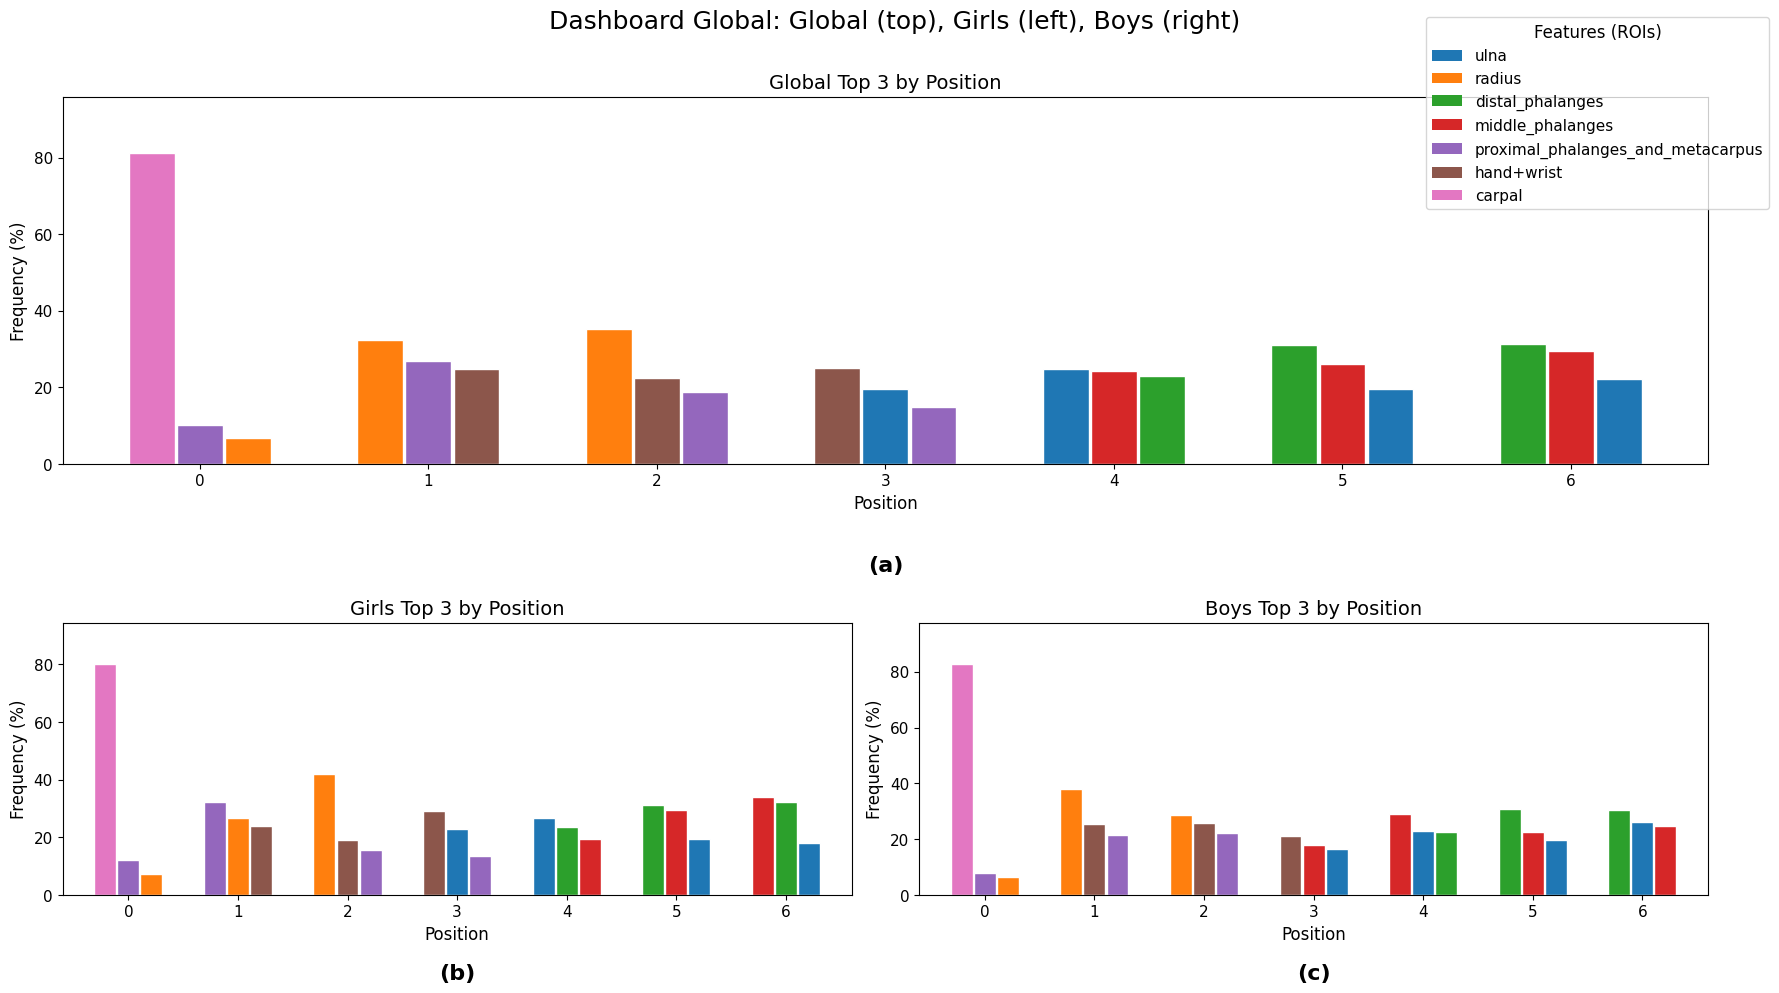

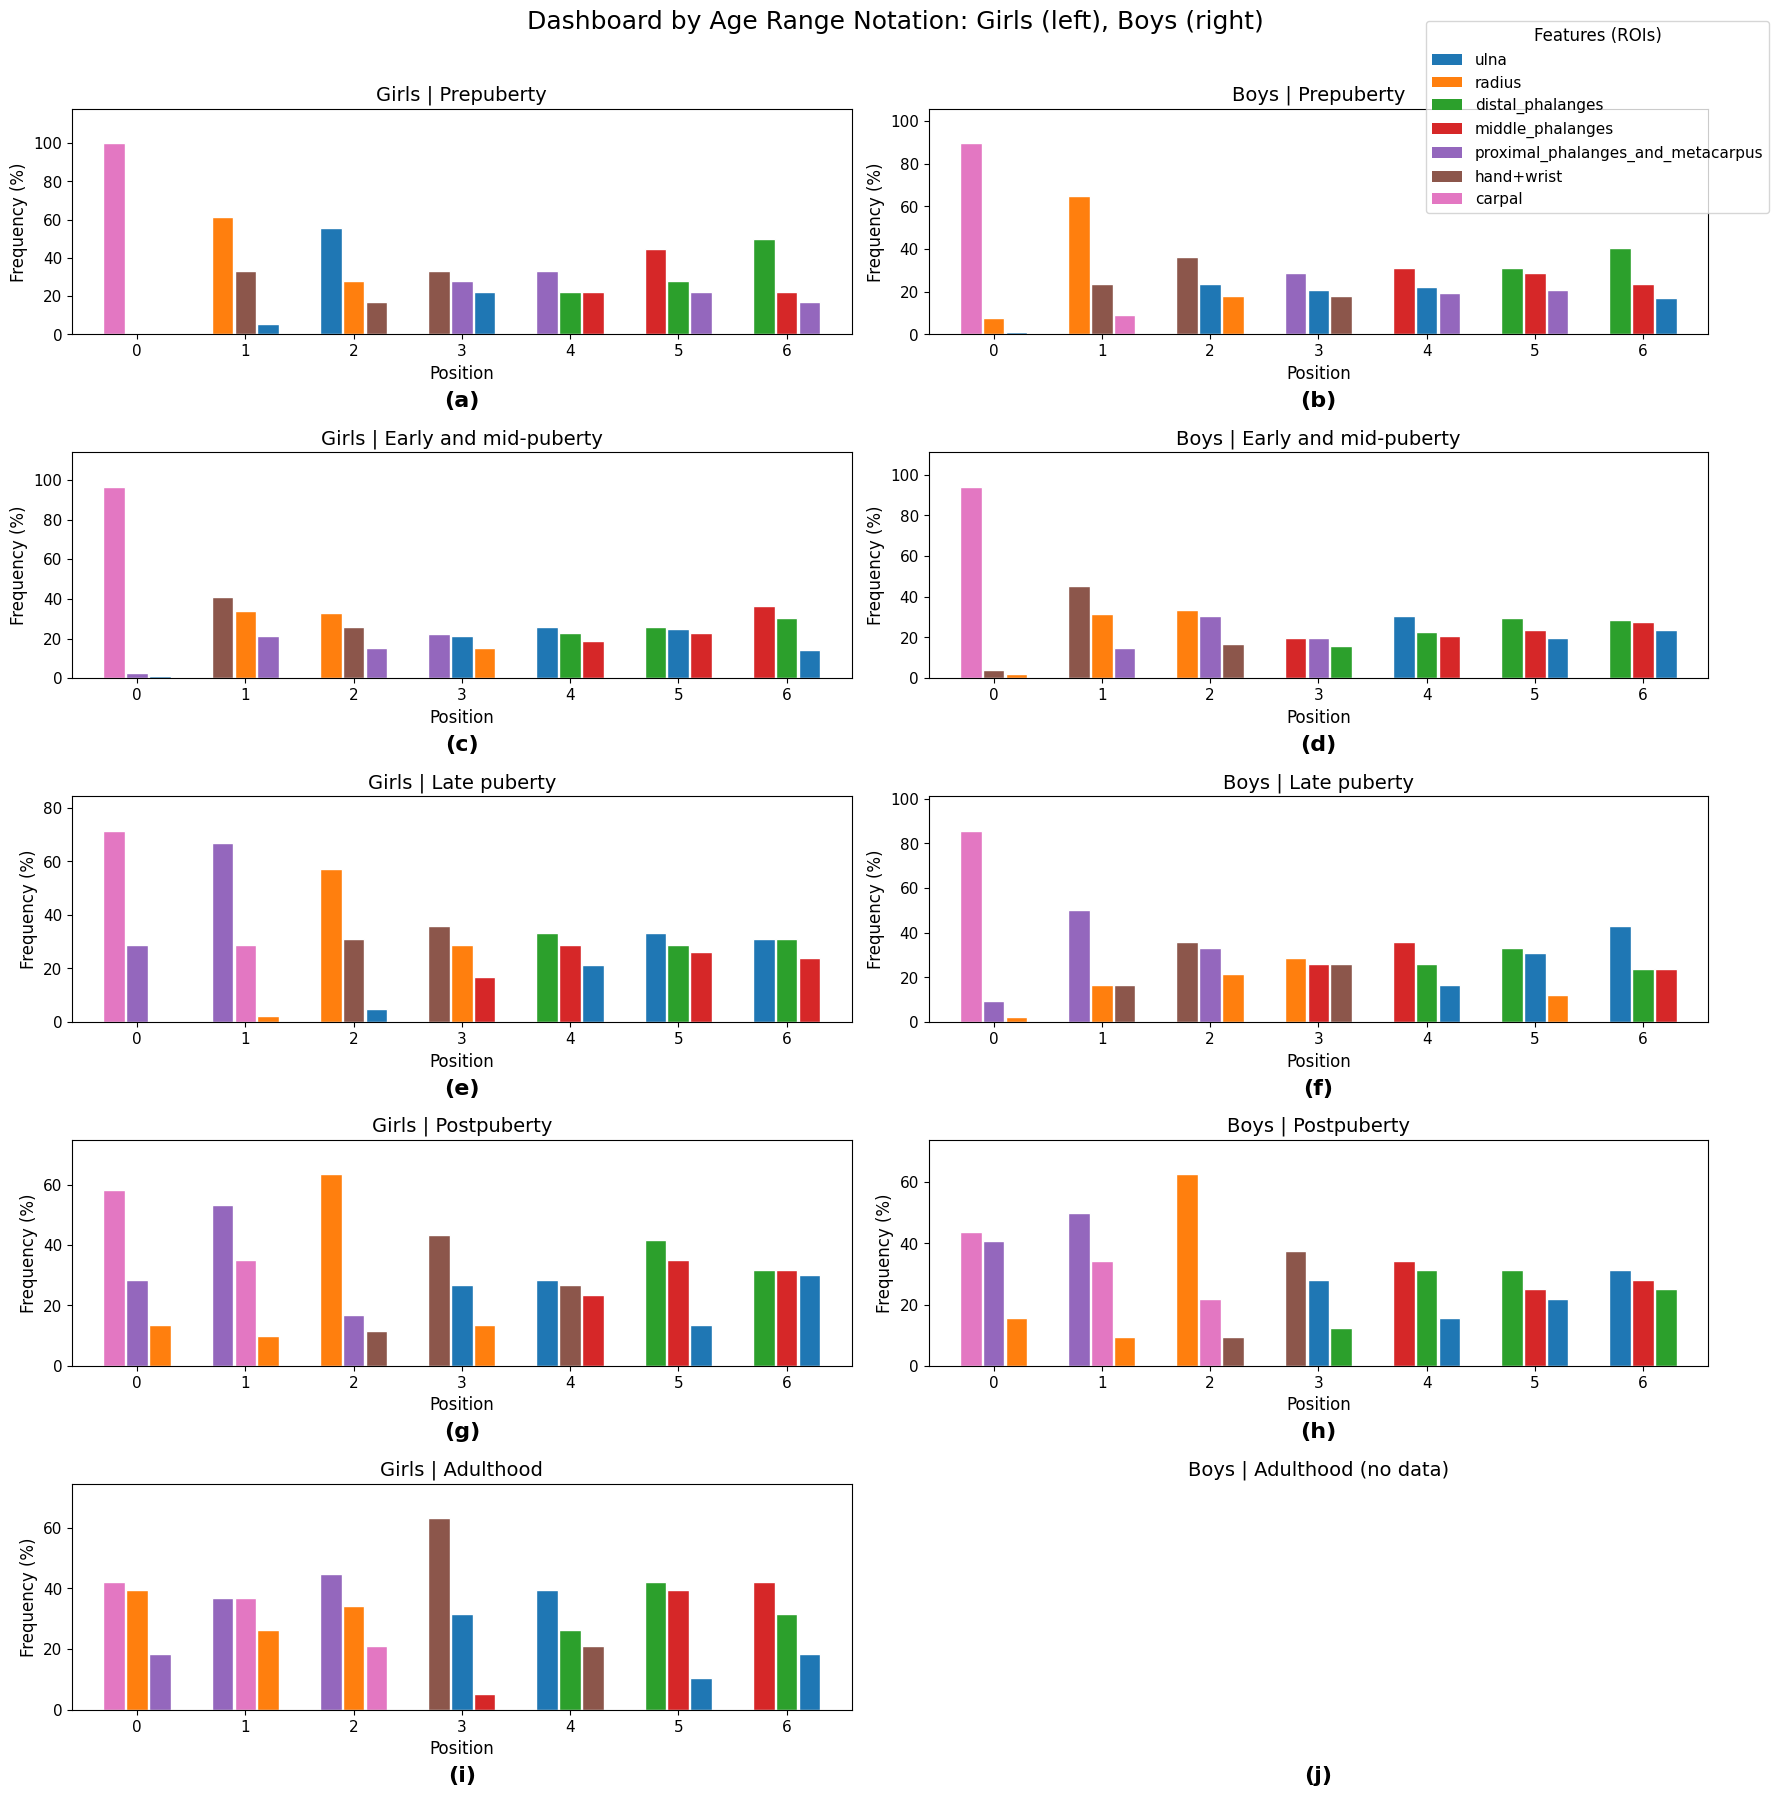

In [10]:
# Dashboard 1: global on top + sex split below
import string
from matplotlib.patches import Patch

# General font scale for dashboard readability
TITLE_FS = 14
AXIS_LABEL_FS = 12
TICK_FS = 11
LEGEND_FS = 11
LEGEND_TITLE_FS = 12
SUPTITLE_FS = 18
PANEL_LABEL_FS = 16

LETTERS = string.ascii_lowercase

def _prepare_filtered_df(df_results, sex=None, age_range=None):
    work_df = df_results.copy()

    # Ensure best_permutation is list[int]
    sample = work_df['best_permutation'].dropna().iloc[0]
    if not isinstance(sample, list):
        work_df['best_permutation'] = (
            work_df['best_permutation']
            .astype(str)
            .str.replace('[', '', regex=False)
            .str.replace(']', '', regex=False)
            .str.replace('  ', ' ', regex=False)
            .str.split(' ')
        )
        work_df['best_permutation'] = work_df['best_permutation'].apply(lambda x: [int(i) for i in x if i != ''])

    if sex is not None:
        work_df = work_df[work_df['sex'] == sex]

    if age_range is not None:
        min_age, max_age = age_range
        work_df = work_df[(work_df['gp'] >= min_age) & (work_df['gp'] <= max_age)]

    return work_df

def _compute_topn(df_filtered, obb_cls, top_n=3):
    if df_filtered.empty:
        return pd.DataFrame(columns=['position', 'joint', 'count', 'joint_name', 'pct', 'n_samples'])

    joint_ids = sorted(obb_cls.keys())
    position_joint = pd.DataFrame(df_filtered['best_permutation'].tolist())
    n_positions = position_joint.shape[1]
    position_joint.columns = range(n_positions)

    freq_df = (
        position_joint
        .melt(var_name='position', value_name='joint')
        .query('joint in @joint_ids')
        .groupby(['position', 'joint'])
        .size()
        .reset_index(name='count')
    )

    all_combinations = pd.MultiIndex.from_product([range(n_positions), joint_ids], names=['position', 'joint']).to_frame(index=False)
    freq_df = all_combinations.merge(freq_df, on=['position', 'joint'], how='left').fillna({'count': 0})
    freq_df['count'] = freq_df['count'].astype(int)
    freq_df['joint_name'] = freq_df['joint'].map(obb_cls)

    topn_df = (
        freq_df.sort_values(['position', 'count'], ascending=[True, False])
        .groupby('position', as_index=False, group_keys=False)
        .head(top_n)
        .copy()
        .sort_values(['position', 'count'], ascending=[True, False])
    )
    topn_df['pct'] = 100 * topn_df['count'] / len(df_filtered)
    topn_df['n_samples'] = len(df_filtered)
    return topn_df

def _plot_topn_on_ax(ax, topn_df, title, color_map, top_n=3, panel_label=None):
    if topn_df.empty:
        ax.set_title(f"{title} (no data)", fontsize=TITLE_FS)
        ax.axis('off')
        if panel_label:
            ax.text(0.5, -0.25, panel_label, transform=ax.transAxes,
                    fontsize=PANEL_LABEL_FS, fontweight='bold', va='top', ha='center', clip_on=False)
        return

    positions = sorted(topn_df['position'].unique())
    bar_width = 0.8 / (top_n + 0.8)
    offsets = np.linspace(-bar_width * (top_n - 1) / 2, bar_width * (top_n - 1) / 2, top_n)

    for pos in positions:
        sub = topn_df[topn_df['position'] == pos].sort_values('count', ascending=False).reset_index(drop=True)
        for i, row in sub.iterrows():
            x = pos + offsets[i]
            ax.bar(x, row['pct'], width=bar_width * 0.95, color=color_map[row['joint_name']], edgecolor='white')

    ax.set_title(title, fontsize=TITLE_FS)
    ax.set_xlabel('Position', fontsize=AXIS_LABEL_FS)
    ax.set_ylabel('Frequency (%)', fontsize=AXIS_LABEL_FS)
    ax.set_xticks(positions)
    ax.set_xticklabels(positions)
    ax.tick_params(axis='both', labelsize=TICK_FS)
    ax.set_xlim(min(positions) - 0.6, max(positions) + 0.6)
    ax.set_ylim(0, topn_df['pct'].max() * 1.18)

    if panel_label:
        ax.text(0.5, -0.25, panel_label, transform=ax.transAxes,
                fontsize=PANEL_LABEL_FS, fontweight='bold', va='top', ha='center', clip_on=False)

top_n = 3
joint_order = [obb_cls[i] for i in sorted(obb_cls.keys())]
palette = sns.color_palette('tab10', n_colors=len(joint_order))
color_map = dict(zip(joint_order, palette))
legend_handles = [Patch(facecolor=color_map[joint], label=joint) for joint in joint_order]

# Figure 1: Global dashboard (global on top, sex split below)
fig1 = plt.figure(figsize=(18, 10))
gs1 = fig1.add_gridspec(nrows=2, ncols=2, height_ratios=[1.35, 1])

ax_global = fig1.add_subplot(gs1[0, :])
df_global = _prepare_filtered_df(df, sex=None, age_range=None)
topn_global = _compute_topn(df_global, obb_cls, top_n=top_n)
_plot_topn_on_ax(ax_global, topn_global, 'Global Top 3 by Position', color_map, top_n=top_n, panel_label='(a)')

ax_female = fig1.add_subplot(gs1[1, 0])
df_female = _prepare_filtered_df(df, sex=100, age_range=None)
topn_female = _compute_topn(df_female, obb_cls, top_n=top_n)
_plot_topn_on_ax(ax_female, topn_female, 'Girls Top 3 by Position', color_map, top_n=top_n, panel_label='(b)')

ax_male = fig1.add_subplot(gs1[1, 1])
df_male = _prepare_filtered_df(df, sex=200, age_range=None)
topn_male = _compute_topn(df_male, obb_cls, top_n=top_n)
_plot_topn_on_ax(ax_male, topn_male, 'Boys Top 3 by Position', color_map, top_n=top_n, panel_label='(c)')

fig1.legend(
    handles=legend_handles,
    title='Features (ROIs)',
    loc='upper right',
    bbox_to_anchor=(0.99, 0.995),
    fontsize=LEGEND_FS,
    title_fontsize=LEGEND_TITLE_FS
)
fig1.suptitle('Dashboard Global: Global (top), Girls (left), Boys (right)', fontsize=SUPTITLE_FS, y=0.995)
plt.tight_layout(rect=[0, 0, 0.96, 0.985])
plt.show()

# Figure 2: Dashboard by age range (girls left, boys right)
girls_groups = [
    {'group': 'Prepuberty', 'age_label': '2-7', 'qty': 3, 'range': (2, 7)},
    {'group': 'Early and mid-puberty', 'age_label': '7-13', 'qty': 18, 'range': (7, 13)},
    {'group': 'Late puberty', 'age_label': '13-15', 'qty': 6, 'range': (13, 15)},
    {'group': 'Postpuberty', 'age_label': '15-17', 'qty': 7, 'range': (15, 17)},
    {'group': 'Adulthood', 'age_label': '>17', 'qty': 2, 'range': (17, 30)},
]

boys_groups = [
    {'group': 'Prepuberty', 'age_label': '3-9', 'qty': 20, 'range': (3, 9)},
    {'group': 'Early and mid-puberty', 'age_label': '9-14', 'qty': 16, 'range': (9, 14)},
    {'group': 'Late puberty', 'age_label': '14-16', 'qty': 14, 'range': (14, 16)},
    {'group': 'Postpuberty', 'age_label': '17-19', 'qty': 2, 'range': (17, 19)},
    {'group': 'Adulthood', 'age_label': '>19', 'qty': 0, 'range': (19, 30)},
]

n_rows = max(len(girls_groups), len(boys_groups))
fig2 = plt.figure(figsize=(18, 3.6 * n_rows))
gs2 = fig2.add_gridspec(nrows=n_rows, ncols=2)

for r, g in enumerate(girls_groups):
    ax_g = fig2.add_subplot(gs2[r, 0])
    df_g = _prepare_filtered_df(df, sex=100, age_range=g['range'])
    topn_g = _compute_topn(df_g, obb_cls, top_n=top_n)
    title_g = f"Girls | {g['group']}"
    _plot_topn_on_ax(ax_g, topn_g, title_g, color_map, top_n=top_n, panel_label=f'({LETTERS[2*r]})')

for r, b in enumerate(boys_groups):
    ax_b = fig2.add_subplot(gs2[r, 1])
    df_b = _prepare_filtered_df(df, sex=200, age_range=b['range'])
    topn_b = _compute_topn(df_b, obb_cls, top_n=top_n)
    title_b = f"Boys | {b['group']}"
    _plot_topn_on_ax(ax_b, topn_b, title_b, color_map, top_n=top_n, panel_label=f'({LETTERS[2*r + 1]})')

fig2.legend(
    handles=legend_handles,
    title='Features (ROIs)',
    loc='upper right',
    bbox_to_anchor=(0.99, 0.995),
    fontsize=LEGEND_FS,
    title_fontsize=LEGEND_TITLE_FS
)
fig2.suptitle('Dashboard by Age Range Notation: Girls (left), Boys (right)', fontsize=SUPTITLE_FS, y=0.997)
plt.tight_layout(rect=[0, 0, 0.96, 0.985])

## Heatmap frequency distribution by stage of maturation

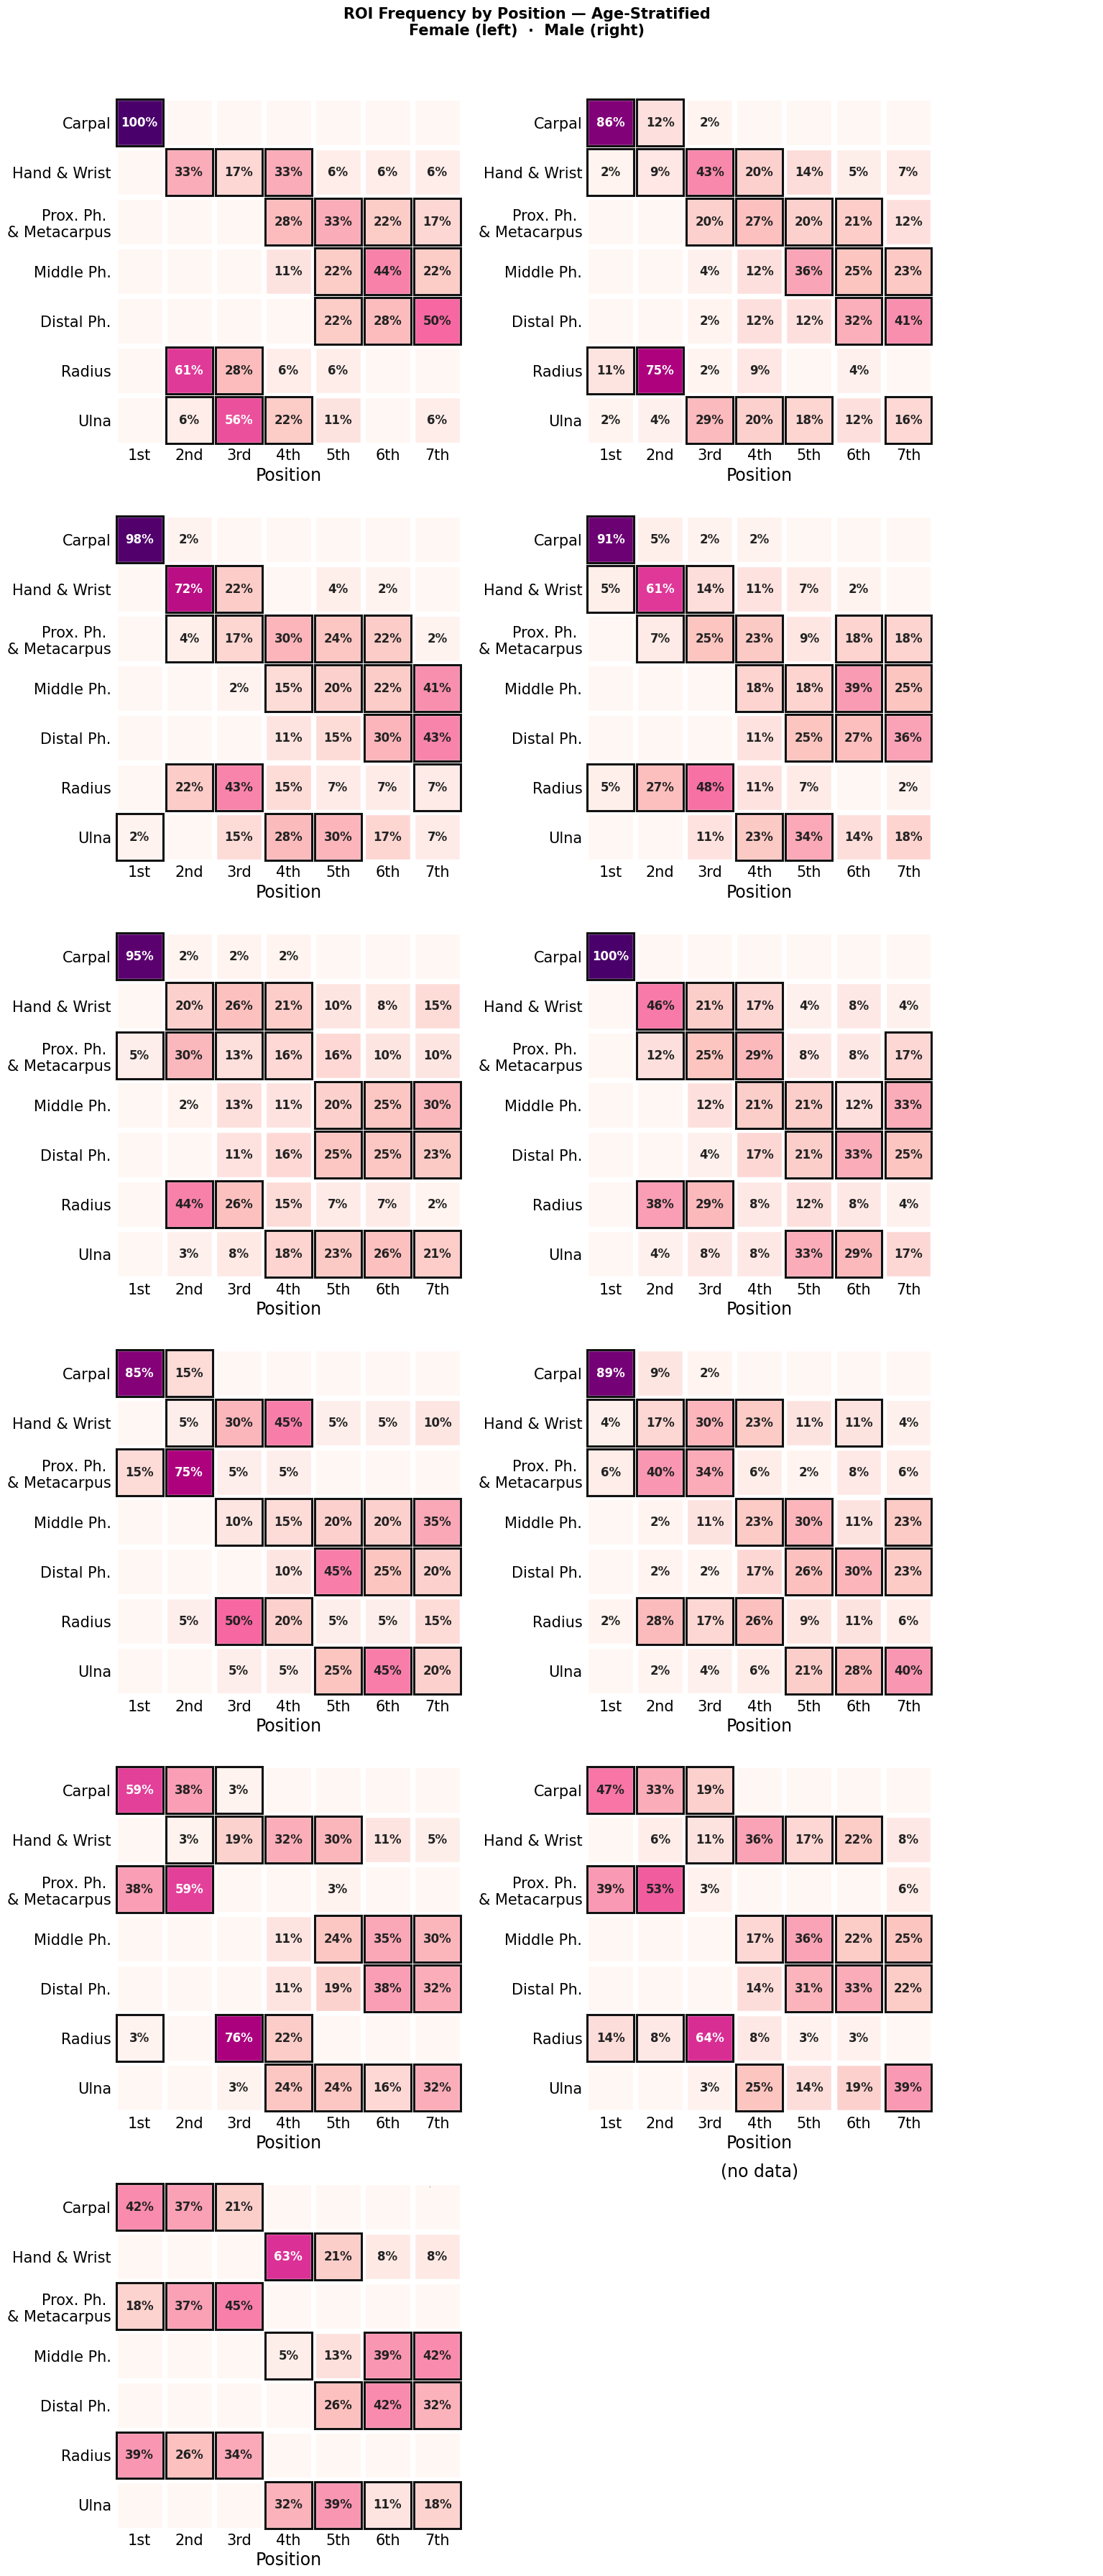

In [11]:
 # Dashboard — heatmap tiles: position × joint frequency
import string
from matplotlib.colors import Normalize
from matplotlib.patches import Rectangle

TITLE_FS    = 17
AXIS_FS     = 17
TICK_FS     = 15
SUPTITLE_FS = 15
PANEL_FS    = 0
LETTERS     = string.ascii_lowercase
ORDINALS    = ['1st', '2nd', '3rd', '4th', '5th', '6th', '7th']
CMAP        = 'RdPu' #RdBu_r'

DISPLAY_NAMES = {
    'ulna':                               'Ulna',
    'radius':                             'Radius',
    'distal_phalanges':                   'Distal Ph.',
    'middle_phalanges':                   'Middle Ph.',
    'proximal_phalanges_and_metacarpus':  'Prox. Ph. \n& Metacarpus',
    'hand+wrist':                         'Hand & Wrist',
    'carpal':                             'Carpal',
}

def _prepare_filtered_df(df_results, sex=None, age_range=None):
    work_df = df_results.copy()
    sample = work_df['best_permutation'].dropna().iloc[0]
    if not isinstance(sample, list):
        work_df['best_permutation'] = (
            work_df['best_permutation']
            .astype(str)
            .str.replace('[', '', regex=False)
            .str.replace(']', '', regex=False)
            .str.replace('  ', ' ', regex=False)
            .str.split(' ')
        )
        work_df['best_permutation'] = work_df['best_permutation'].apply(
            lambda x: [int(i) for i in x if i != ''])
    if sex is not None:
        work_df = work_df[work_df['sex'] == sex]
    if age_range is not None:
        lo, hi = age_range
        work_df = work_df[(work_df['gp'] >= lo) & (work_df['gp'] < hi)]
    return work_df

def _compute_freq_matrix(df_filtered, obb_cls):
    if df_filtered.empty:
        return pd.DataFrame(), 0
    joint_ids = sorted(obb_cls.keys())
    pos_jnt = pd.DataFrame(df_filtered['best_permutation'].tolist())
    n_pos = pos_jnt.shape[1]
    pos_jnt.columns = range(n_pos)
    freq = (
        pos_jnt.melt(var_name='position', value_name='joint')
        .query('joint in @joint_ids')
        .groupby(['position', 'joint']).size().reset_index(name='count')
    )
    all_comb = pd.MultiIndex.from_product(
        [range(n_pos), joint_ids], names=['position', 'joint']
    ).to_frame(index=False)
    freq = all_comb.merge(freq, on=['position', 'joint'], how='left').fillna({'count': 0})
    freq['count'] = freq['count'].astype(int)
    freq['pct'] = 100 * freq['count'] / len(df_filtered)
    matrix = freq.pivot(index='joint', columns='position', values='pct').reindex(joint_ids)
    matrix.index = [DISPLAY_NAMES.get(obb_cls[j], obb_cls[j]) for j in joint_ids]
    return matrix, len(df_filtered)

def _plot_heatmap_on_ax(ax, matrix, n_samples, title, top_n=3, font_size_=12,panel_label=None):
    if matrix.empty:
        ax.set_title(f"{title}\n(no data)", fontsize=TITLE_FS)
        ax.axis('off')
        if panel_label:
            ax.text(0.01, 0.99, panel_label, transform=ax.transAxes,
                    fontsize=PANEL_FS, fontweight='bold', va='top', ha='left')
        return

    data          = matrix.values          # shape: (n_joints, n_positions)
    n_joints, n_pos = data.shape
    joint_labels  = list(matrix.index)
    cmap_obj      = plt.get_cmap(CMAP)
    norm          = Normalize(vmin=0, vmax=100)

    # Background tiles
    for j in range(n_joints):
        for p in range(n_pos):
            val = data[j, p]
            ax.add_patch(Rectangle(
                (p - 0.47, j - 0.47), 0.94, 0.94,
                facecolor=cmap_obj(norm(val)), edgecolor='white', linewidth=2.5, zorder=1
            ))
            if val > 0:
                ax.text(p, j, f"{val:.0f}%", ha='center', va='center',
                        fontsize=font_size_, zorder=1, fontweight='bold',
                        color='white' if val > 55 else '#222222')

    # Bold border on top_n tiles per position
    for p in range(n_pos):
        for j in np.argsort(data[:, p])[::-1][:top_n]:
            if data[j, p] > 0:
                ax.add_patch(Rectangle(
                    (p - 0.47, j - 0.47), 0.94, 0.94,
                    facecolor='none', edgecolor='#111111', linewidth=2.2, zorder=3
                ))

    ax.set_xlim(-0.5, n_pos - 0.5)
    ax.set_ylim(-0.5, n_joints - 0.5)
    ax.set_aspect('equal', adjustable='box')
    ax.set_box_aspect(1)
    ax.set_xticks(range(n_pos))
    ax.set_xticklabels(ORDINALS[:n_pos], fontsize=TICK_FS)
    ax.set_yticks(range(n_joints))
    ax.set_yticklabels(joint_labels, fontsize=TICK_FS)
    ax.set_xlabel('Position', fontsize=AXIS_FS)
    # ax.set_title(f"{title}  (n = {n_samples})", fontsize=TITLE_FS, pad=6)

    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(length=0)

    if panel_label:
        ax.text(0.47, -0.10, panel_label, transform=ax.transAxes,
                fontsize=PANEL_FS, fontweight='bold', va='top', ha='left')

top_n = 3

# # ── Figure 1: Global / Girls / Boys ──────────────────────────────────────────
# fig1, axes1 = plt.subplots(1, 3, figsize=(22, 8), gridspec_kw={'wspace': 0.08})
# for ax, (sex_val, lbl, panel) in zip(axes1, [
#     (None, 'Global', '(a)'),
#     (100,  'Girls',  '(b)'),
#     (200,  'Boys',   '(c)'),
# ]):
#     mat, n = _compute_freq_matrix(_prepare_filtered_df(df, sex=sex_val), obb_cls)
#     _plot_heatmap_on_ax(ax, mat, n, lbl, top_n=top_n, panel_label=panel)

# fig1.suptitle('ROI Frequency by Position — Global, Girls, Boys',
#               fontsize=SUPTITLE_FS, fontweight='bold', y=0.98)
# fig1.subplots_adjust(left=0.025, right=0.995, bottom=0.06, top=0.91, wspace=0.08)
# plt.show()

# ── Figure 2: Age-stratified (Girls left · Boys right) ───────────────────────
girls_groups = [
    {'group': 'Prepuberty',        'range': (2,  7)},
    {'group': 'Early-puberty', 'range': (7,  10)},
    {'group': 'Mid-puberty', 'range': (10,  13)},
    {'group': 'Late puberty',      'range': (13, 15)},
    {'group': 'Postpuberty',       'range': (15, 17)},
    {'group': 'Adulthood',         'range': (17, 30)},
]
boys_groups = [
    {'group': 'Prepuberty',        'range': (3,  9)},
    {'group': 'Early-puberty', 'range': (9,  11)},
    {'group': 'Mid-puberty', 'range': (11,  13)},
    {'group': 'Late puberty',      'range': (13, 16)},
    {'group': 'Postpuberty',       'range': (16, 19)},
    {'group': 'Adulthood',         'range': (19, 30)},
]
n_rows = max(len(girls_groups), len(boys_groups))
fig2_w = 16
fig2_h = max(16, 6 * n_rows)
fig2, axes2 = plt.subplots(
    n_rows,
    2,
    figsize=(fig2_w, fig2_h),
    gridspec_kw={'hspace': 0.2, 'wspace': - 0.3}
)

for r, g in enumerate(girls_groups):
    mat, n = _compute_freq_matrix(
        _prepare_filtered_df(df, sex=100, age_range=g['range']), obb_cls)
    _plot_heatmap_on_ax(axes2[r, 0], mat, n,
                        " ", #f"Girls | {g['group']} ({g['range'][0]}–{g['range'][1]} yrs)"
                        top_n=top_n, panel_label=f'({LETTERS[3*r]})')

for r, b in enumerate(boys_groups):
    mat, n = _compute_freq_matrix(
        _prepare_filtered_df(df, sex=200, age_range=b['range']), obb_cls)
    _plot_heatmap_on_ax(axes2[r, 1], mat, n,
                        " ", #f"Boys | {b['group']} ({b['range'][0]}–{b['range'][1]} yrs)"
                        top_n=top_n, panel_label=f'({LETTERS[2*r + 1]})')

fig2.suptitle('ROI Frequency by Position — Age-Stratified\nFemale (left)  ·  Male (right)',
              fontsize=SUPTITLE_FS, fontweight='bold', y=0.995)
fig2.subplots_adjust(left=0.0, right=0.995, bottom=0.02, top=0.96, hspace=0.10, wspace=0.06)
# define image quality for better rendering of small text
plt.rcParams['figure.dpi'] = 100

#save figures
fig2.savefig('dashboard_age_stratified.png', dpi=300)
plt.show()


In [12]:
# 